In [25]:
import pandas as pd
from netmap.downstream.markers import *

In [26]:
marker1 = pd.read_csv('/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/bd-rhap-rep1-markers/marker_gene_jaccard_overlaps.tsv', sep = '\t', index_col=0)
marker2 = pd.read_csv('/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/bd-rhap-rep2-markers/marker_gene_jaccard_overlaps.tsv', sep = '\t', index_col=0)
marker3 = pd.read_csv('/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/10x-rep1-kallisto-cellbender-markers/marker_gene_jaccard_overlaps.tsv', sep = '\t', index_col=0)
marker4 = pd.read_csv('/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/10x-rep2-kallisto-cellbender-markers/marker_gene_jaccard_overlaps.tsv', sep = '\t', index_col=0)

In [27]:
marker1['experiment'] = 'bd-rhap-rep1'
marker2['experiment'] = 'bd-rhap-rep2'
marker3['experiment'] = '10x-rep1-kallisto-cellbender'
marker4['experiment'] = '10x-rep2-kallisto-cellbender'

In [28]:
markers = pd.concat([marker1, marker2, marker3, marker4])
markers.to_csv('/data_nfs/og86asub/netmap/netmap-evaluation/results/figures/data/jaccard_marker_overlap_combined.tsv', sep = '\t')


In [29]:
markers

,celltype,jaccard,ct,type,index,cluster,cluster_name,cluster_high_level,is_mapped,database,experiment
1560,Abnormal myeloid cell,0.000000,DC,Source,Abnormal myeloid cell,11.0,Neutrophils,Neutrophils,off target,cellmarker,bd-rhap-rep1
1561,Activated B cell,0.000000,DC,Source,Activated B cell,2.0,Activated B cells,B cells,off target,cellmarker,bd-rhap-rep1
1562,Activated CD4+ T cell,0.000000,DC,Source,Activated CD4+ T cell,20.0,Naive/Cytotoxic T cell,T cells,off target,cellmarker,bd-rhap-rep1
1563,Activated CD8+ T cell,0.000000,DC,Source,Activated CD8+ T cell,23.0,Activated T cells/ Effector T cells,T cells,off target,cellmarker,bd-rhap-rep1
1564,Activated T cell,0.000000,DC,Source,Activated T cell,16.0,Activated/T helper cells,T cells,off target,cellmarker,bd-rhap-rep1
...,...,...,...,...,...,...,...,...,...,...,...
6,Monocytes,0.008000,NK cell,Target,NaN,NaN,NaN,NaN,off target,pangalaodn,10x-rep2-kallisto-cellbender
7,NK cells,0.150943,NK cell,Target,NaN,NaN,NaN,NaN,on target,pangalaodn,10x-rep2-kallisto-cellbender
8,Natural killer T cells,0.066667,NK cell,Target,NaN,NaN,NaN,NaN,off target,pangalaodn,10x-rep2-kallisto-cellbender
9,T cells,0.056452,NK cell,Target,NaN,NaN,NaN,NaN,off target,pangalaodn,10x-rep2-kallisto-cellbender


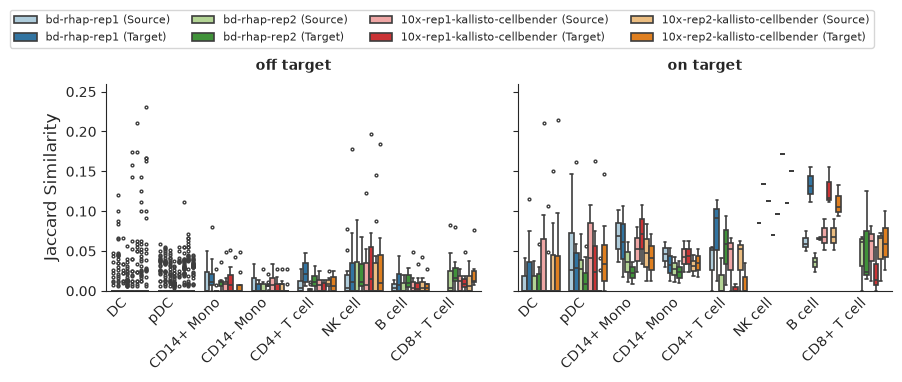

In [33]:
import seaborn as sns

def plot_jaccard_comparison(plot_df, title="", img_path=None):
    """
    Creates a condensed plot where experiments and types are nested 
    side-by-side for direct stability comparison, excluding outliers > 0.25.
    """
    plot_df = plot_df.copy()
    
    # --- STEP 1: Filter Outliers ---
    # We remove any rows where jaccard is greater than 0.25
    plot_df = plot_df[plot_df['jaccard'] <= 0.25]
    
    # 2. Create a combined column for the hue
    plot_df['condition'] = plot_df['experiment'].astype(str) + " (" + plot_df['type'] + ")"
    
    sns.set_style("ticks")
    
    # 3. Plotting
    g = sns.catplot(
        data=plot_df, 
        x='ct', 
        y='jaccard', 
        hue='condition', 
        col='is_mapped', 
        kind='box', 
        palette='Paired',
        height=3, 
        aspect=1.5, 
        linewidth=1.2, 
        fliersize=2, 
        sharey=True
    )

    # Formatting
    g.set_xticklabels(rotation=45, ha='right')
    g.set_axis_labels("", "Jaccard Similarity", fontsize=12)
    g.set_titles("{col_name}", fontweight='bold', pad=10)
    
    sns.move_legend(g, loc="upper left", bbox_to_anchor=(0, 1.15), fontsize=8, frameon=True, ncol=4, title='')
    
    for ax in g.axes.flat:
        ax.tick_params(axis='x', length=0)
        ax.set_ylim(0, 0.26) 
        sns.despine(ax=ax)

    g.fig.suptitle(title, fontweight='bold', fontsize=14, y=1.05)
    
    
    g.savefig(img_path)

    return g

plot_jaccard_comparison(markers, img_path = '/data_nfs/og86asub/netmap/netmap-evaluation/results/figures/plots/jaccard_overlap_with_cluster_markers_detailed.pdf')

/data_nfs/og86asub/netmap/netmap-evaluation/.pixi/envs/default/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self._figure.tight_layout(*args, **kwargs)
/tmp/ipykernel_1807387/3739985622.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(
/data_nfs/og86asub/netmap/netmap-evaluation/.pixi/envs/default/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self._figure.tight_layout(*args, **kwargs)
/data_nfs/og86asub/netmap/netmap-evaluation/.pixi/envs/default/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so resul

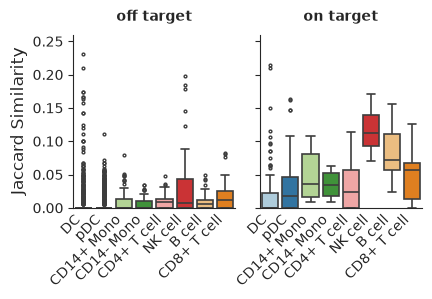

In [32]:
import seaborn as sns

def plot_jaccard_comparison(plot_df, title="", img_path=None):
    """
    Creates a condensed plot where experiments and types are nested 
    side-by-side for direct stability comparison, excluding outliers > 0.25.
    """
    plot_df = plot_df.copy()


    sns.set_style("ticks")
    
    # 3. Plotting
    g = sns.catplot(
        data=plot_df, 
        x='ct', 
        y='jaccard', 
        col='is_mapped', 
        kind='box', 
        palette='Paired',
        height=2.25, 
        aspect=1, 
        linewidth=1.2, 
        fliersize=2, 
        sharey=True,
        facet_kws={'gridspec_kws': {'wspace': 0.15}}
    )

    # Formatting
    g.set_xticklabels(rotation=45, ha='right')
    g.set_axis_labels("", "Jaccard Similarity", fontsize=12)
    g.set_titles("{col_name}", fontweight='bold', pad=10)
    
    for ax in g.axes.flat:
        ax.tick_params(axis='x', length=0)
        ax.set_ylim(0, 0.26) 
        sns.despine(ax=ax)

    g.fig.suptitle(title, fontweight='bold', fontsize=14, y=1.05)
    g.tight_layout()
    
    g.savefig(img_path)

    return g

plot_jaccard_comparison(markers, img_path = '/data_nfs/og86asub/netmap/netmap-evaluation/results/figures/plots/jaccard_overlap_with_cluster_markers.pdf')